In [ ]:
#Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
#load Data & Configure Model Variables

In [2]:
df = pd.read_csv('C:/Users/Mindworx/Downloads/adidas_dataset.csv')
# Define target and explanatory variables
features = ['Category', 'Region', 'Store_Type', 'Units_Sold', 'Unit_Price', 'Discount', 'Customer_Age', 'Gender', 'Payment_Method']
target = 'Revenue'

X = df[features]
y = df[target]

# Split data: 80% to train the model, 20% reserved to evaluate it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Build Preprocessing & Modeling Pipeline

In [3]:
categorical_features = ['Category', 'Region', 'Store_Type', 'Gender', 'Payment_Method']
numerical_features = ['Units_Sold', 'Unit_Price', 'Discount', 'Customer_Age']

# Use One-Hot Encoding for text classes; passthrough numbers as-is
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Pair the processor together inside a unified Random Forest ensemble container
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [ ]:
#Train Model and Generate Key Testing Predictions

In [4]:
rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

In [5]:
#Compute Performance Evaluations

In [6]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== RANDOM FOREST MODEL PERFORMANCE ===")
print(f"R2 Score (Variance Explained): {r2:.4f}")
print(f"Mean Absolute Error (MAE):     ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}\n")

=== RANDOM FOREST MODEL PERFORMANCE ===
R2 Score (Variance Explained): 0.9739
Mean Absolute Error (MAE):     $12.21
Root Mean Squared Error (RMSE): $31.61



In [ ]:
#Extract & Plot Feature Importances

C:\Users\Mindworx\AppData\Local\Temp\ipykernel_31300\799274334.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_df.head(10), x='Importance', y='Feature', palette='viridis', ax=ax)


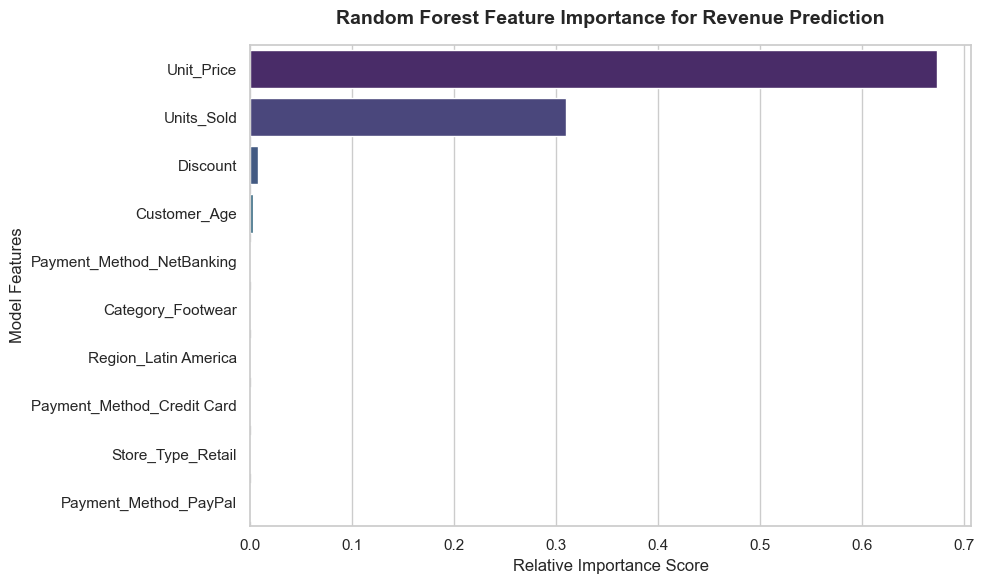

In [8]:
ohe_cols = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = numerical_features + list(ohe_cols)
importances = rf_pipeline.named_steps['regressor'].feature_importances_

importances_df = pd.DataFrame({'Feature': all_features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Visualizing Top 10 Features
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importances_df.head(10), x='Importance', y='Feature', palette='viridis', ax=ax)
ax.set_title('Random Forest Feature Importance for Revenue Prediction', fontsize=14, pad=15, weight='bold')
ax.set_xlabel('Relative Importance Score', fontsize=12)
ax.set_ylabel('Model Features', fontsize=12)
plt.tight_layout()

In [ ]:
#Plot Fitment Line: Actual vs. Predictions

Model script execution completed! Visuals are exported successfully.


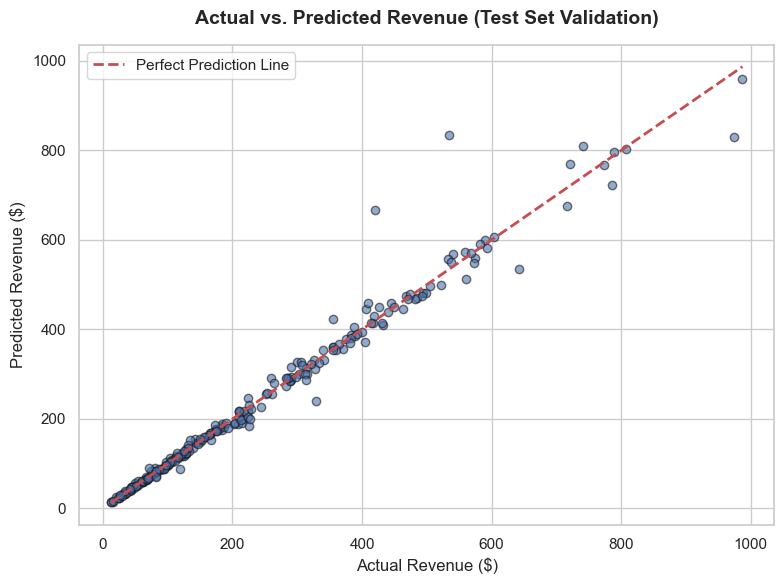

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.6, color='b', edgecolors='k')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
ax.set_xlabel('Actual Revenue ($)', fontsize=12)
ax.set_ylabel('Predicted Revenue ($)', fontsize=12)
ax.set_title('Actual vs. Predicted Revenue (Test Set Validation)', fontsize=14, pad=15, weight='bold')
ax.legend()
plt.tight_layout()

print("Model script execution completed! Visuals are exported successfully.")